# Explore here

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np

url = "https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"


df = pd.read_csv(url, sep=';')

In [4]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [6]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [7]:
print(df.columns.tolist())

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


In [8]:
df['quality'].value_counts()


quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [9]:
def calidades(quality):
    if quality <= 4:
        return 0
    elif quality in [5, 6]:
        return 1 
    else:
        return 2 

In [10]:
df['label'] = df['quality'].apply(calidades)
print("\nDistribución de la columna'label' :")
print(df['label'].value_counts())


Distribución de la columna'label' :
label
1    1319
2     217
0      63
Name: count, dtype: int64


In [11]:
X = df.drop(['label', 'quality'], axis=1)
y = df['label']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

In [31]:
print("\nPrecisión con n= 2:", accuracy)


Precisión con n= 2: 0.80625


In [14]:
print(confusion_matrix(y_test, y_pred))

[[  0  11   0]
 [  1 250  11]
 [  0  27  20]]


In [15]:
print(classification_report(y_test, y_pred, target_names=['Baja', 'Media', 'Alta']))

              precision    recall  f1-score   support

        Baja       0.00      0.00      0.00        11
       Media       0.87      0.95      0.91       262
        Alta       0.65      0.43      0.51        47

    accuracy                           0.84       320
   macro avg       0.50      0.46      0.47       320
weighted avg       0.81      0.84      0.82       320



In [16]:
valores = range(1, 21)
precisiones = []

for k in valores:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    precisiones.append(acc)
    print(f"Precisión para cada valor k={k}: {acc}")

Precisión para cada valor k=1: 0.846875
Precisión para cada valor k=2: 0.80625
Precisión para cada valor k=3: 0.834375
Precisión para cada valor k=4: 0.85
Precisión para cada valor k=5: 0.84375
Precisión para cada valor k=6: 0.85
Precisión para cada valor k=7: 0.846875
Precisión para cada valor k=8: 0.840625
Precisión para cada valor k=9: 0.840625
Precisión para cada valor k=10: 0.84375
Precisión para cada valor k=11: 0.840625
Precisión para cada valor k=12: 0.846875
Precisión para cada valor k=13: 0.846875
Precisión para cada valor k=14: 0.85625
Precisión para cada valor k=15: 0.85625
Precisión para cada valor k=16: 0.83125
Precisión para cada valor k=17: 0.83125
Precisión para cada valor k=18: 0.828125
Precisión para cada valor k=19: 0.834375
Precisión para cada valor k=20: 0.821875


In [25]:
mejores = valores[np.argmax(precisiones)]
mejorprec = max(precisiones)
print(f"\nMejor valor: {mejores} precisión: {mejorprec}")
#Tenemos una precisión del 86%


Mejor valor: 14 precisión: 0.85625


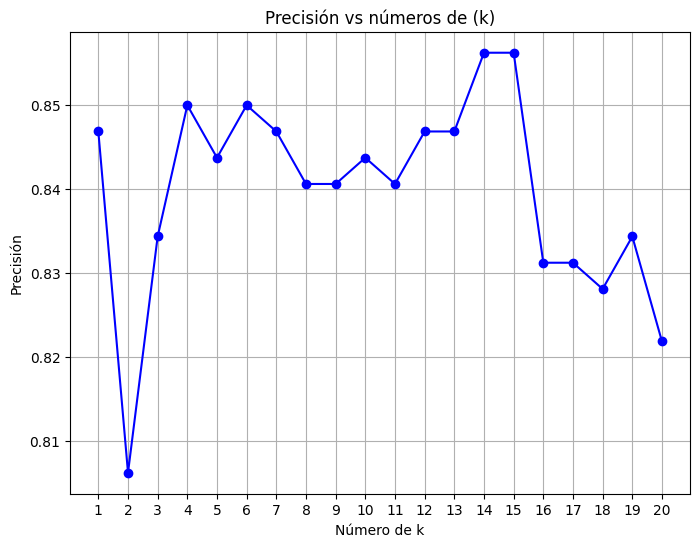

In [28]:
plt.figure(figsize=(8, 6))
plt.plot(valores, precisiones, marker='o', linestyle='-', color='b')
plt.title('Precisión vs números de (k)')
plt.xlabel('Número de k')
plt.ylabel('Precisión')
plt.grid(True)
plt.xticks(valores)
plt.savefig('precisiónPorK.png')

In [24]:
#Entrenamos el con el mejor valor
mejorTotal = KNeighborsClassifier(n_neighbors=mejores)
mejorTotal.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=14)

In [26]:
#Predicciones:
def predict_wine_quality(features):
    features_scaled = scaler.transform([features])
    pred = mejorTotal.predict(features_scaled)[0]
    if pred == 0:
        return "Este vino probablemente sea de baja calidad 🍷"
    elif pred == 1:
        return "Este vino probablemente sea de calidad media 🍷"
    elif pred == 2:
        return "Este vino probablemente sea de alta calidad 🍷"
    else:
        return "Algo ha ido mal"

In [27]:
resultado = predict_wine_quality([7.4, 0.7, 0.0, 1.9, 0.076,
                                  11.0, 34.0, 0.9978, 3.51, 0.56, 9.4])
print("\nPredicción de ejemplo:", resultado)


Predicción de ejemplo: Este vino probablemente sea de calidad media 🍷


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
